# M1M9：Peak-weighted MSE ANN + EnbPI

此實驗不修改原本的 `KF_m1m9_EnbPI.ipynb`。低頻 ARIMA、moving-block bootstrap、OOB/LOO、bias correction 與 EnbPI 全部維持原流程；唯一改動是高頻 ANN 的 MSE 對稀有大振幅 target 給較高權重。

預設以 bootstrap training targets 相對其中位數的絕對偏差定義尖峰：最高 10% 權重為 3，其餘權重為 1。baseline 與 weighted 版本使用完全相同的 data seeds，最後以 paired difference 判斷是否改善。

In [1]:
from pathlib import Path
import sys
import pandas as pd

cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    if (candidate / 'src' / 'kf_forecasting').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError('找不到 project/meeting 專案根目錄')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from kf_forecasting.models.kf_enbpi import (
    EnbPIConfig,
    monte_carlo_summary,
    plot_monte_carlo_forecast_diagnostics,
    plot_monte_carlo_summary,
)
from kf_forecasting.models.kf_peak_weighted_enbpi import (
    PeakWeightedEnbPIConfig,
    paired_peak_comparison,
    peak_weighted_monte_carlo_summary,
)

In [2]:
common_config = dict(
    window_size=15,
    alpha=0.05,
    n_bootstrap=30,
    block_length=None,
    batch_size=1,
    beta_grid_size=101,
    oob_bias_correction=True,
    oob_bias_correction_mode='combined',
    arima_order=None,
    arima_max_p=4,
    arima_max_q=4,
    ann_hidden_layers=(32, 16),
    ann_max_iter=500,
    ann_alpha=1e-4,
    ann_learning_rate_init=1e-3,
    ann_target_standardization=True,
    ann_early_stopping=False,
    ann_rolling_validation=True,
    ann_rolling_splits=3,
    ann_validation_fraction=0.10,
    ann_iteration_candidates=(125, 250, 500),
    ann_tol=1e-3,
    random_state=1234,
    process_variance=0.5,
    measurement_variance=10.0,
)
baseline_config = EnbPIConfig(**common_config)
weighted_config = PeakWeightedEnbPIConfig(
    **common_config,
    ann_peak_quantile=0.90,
    ann_peak_weight=3.0,
)

train_size = 650
horizon = 200
n_runs = 20
monte_carlo_seed = 2026

In [3]:
baseline_runs, baseline_summary, baseline_results = monte_carlo_summary(
    'm1m9',
    n_runs=n_runs,
    train_size=train_size,
    horizon=horizon,
    config=baseline_config,
    seed=monte_carlo_seed,
)
weighted_runs, weighted_summary, weighted_results = peak_weighted_monte_carlo_summary(
    'm1m9',
    n_runs=n_runs,
    train_size=train_size,
    horizon=horizon,
    config=weighted_config,
    seed=monte_carlo_seed,
)
paired_runs, paired_summary = paired_peak_comparison(
    baseline_runs,
    baseline_results,
    weighted_runs,
    weighted_results,
    peak_quantile=weighted_config.ann_peak_quantile,
)

In [4]:
display(paired_summary)
display(paired_runs)

# 正值代表 weighted 版本比較好。首先看 tail RMSE 是否下降，再看整體 RMSE 是否付出太大代價。
key_metrics = paired_summary[paired_summary['metric'].isin([
    'rmse_gain_baseline_minus_weighted',
    'tail_rmse_gain_baseline_minus_weighted',
    'baseline_coverage',
    'weighted_coverage',
    'baseline_width',
    'weighted_width',
    'baseline_peak_recall',
    'weighted_peak_recall',
    'baseline_peak_amplitude_ratio',
    'weighted_peak_amplitude_ratio',
])]
display(key_metrics)

,metric,mean,std
0,baseline_rmse,1.942862,0.139942
1,weighted_rmse,1.946540,0.130511
2,rmse_gain_baseline_minus_weighted,-0.003678,0.019152
3,baseline_kf_high_tail_rmse,2.927405,0.270622
4,weighted_kf_high_tail_rmse,2.869963,0.269981
5,tail_rmse_gain_baseline_minus_weighted,0.057443,0.051210
6,baseline_coverage,0.945250,0.018244
7,weighted_coverage,0.943750,0.015207
8,baseline_width,7.553825,0.287460
9,weighted_width,7.616094,0.311601


,run,data_seed,baseline_rmse,weighted_rmse,rmse_gain_baseline_minus_weighted,baseline_kf_high_tail_rmse,weighted_kf_high_tail_rmse,tail_rmse_gain_baseline_minus_weighted,baseline_coverage,weighted_coverage,baseline_width,weighted_width,baseline_peak_recall,weighted_peak_recall,baseline_peak_amplitude_ratio,weighted_peak_amplitude_ratio
0,1,479243620,1.903279,1.915874,-0.012595,3.004265,2.936544,0.067721,0.930,0.930,7.044722,7.090378,0.00,0.00,0.274305,0.302046
1,2,454024514,1.909574,1.907404,0.002170,2.725224,2.605384,0.119840,0.950,0.955,7.461888,7.668836,0.05,0.05,0.351008,0.396749
2,3,1818751028,1.619379,1.637184,-0.017805,2.560718,2.579963,-0.019245,0.970,0.975,7.289171,7.330822,0.05,0.15,0.337151,0.371877
3,4,2288458700,2.036706,2.055523,-0.018817,3.072602,3.028052,0.044550,0.930,0.920,7.876727,7.811072,0.00,0.05,0.319652,0.334797
4,5,2115331525,1.922648,1.918758,0.003890,2.743765,2.696440,0.047325,0.965,0.955,7.735265,7.871094,0.00,0.00,0.275868,0.299521
5,6,2666256175,2.036351,2.021260,0.015091,2.840509,2.726502,0.114007,0.900,0.930,7.296539,7.309606,0.00,0.10,0.350796,0.402324
6,7,975381835,1.934744,1.946037,-0.011294,3.362784,3.356091,0.006693,0.915,0.925,7.381922,7.314783,0.10,0.10,0.257587,0.287942
7,8,2535166222,1.985142,2.003466,-0.018325,3.268139,3.232407,0.035732,0.945,0.925,7.714522,7.798805,0.00,0.00,0.170388,0.193756
8,9,1079577930,2.121127,2.078358,0.042769,3.116720,3.065613,0.051107,0.930,0.925,7.979576,8.136532,0.00,0.00,0.276626,0.310776
9,10,3715024065,1.921286,1.929252,-0.007966,2.915668,2.759547,0.156121,0.950,0.945,7.535527,7.557952,0.05,0.10,0.287256,0.336191


,metric,mean,std
2,rmse_gain_baseline_minus_weighted,-0.003678,0.019152
5,tail_rmse_gain_baseline_minus_weighted,0.057443,0.051210
6,baseline_coverage,0.945250,0.018244
7,weighted_coverage,0.943750,0.015207
8,baseline_width,7.553825,0.287460
9,weighted_width,7.616094,0.311601
10,baseline_peak_recall,0.027500,0.041279
11,weighted_peak_recall,0.057500,0.051999
12,baseline_peak_amplitude_ratio,0.304481,0.062561
13,weighted_peak_amplitude_ratio,0.339384,0.066489


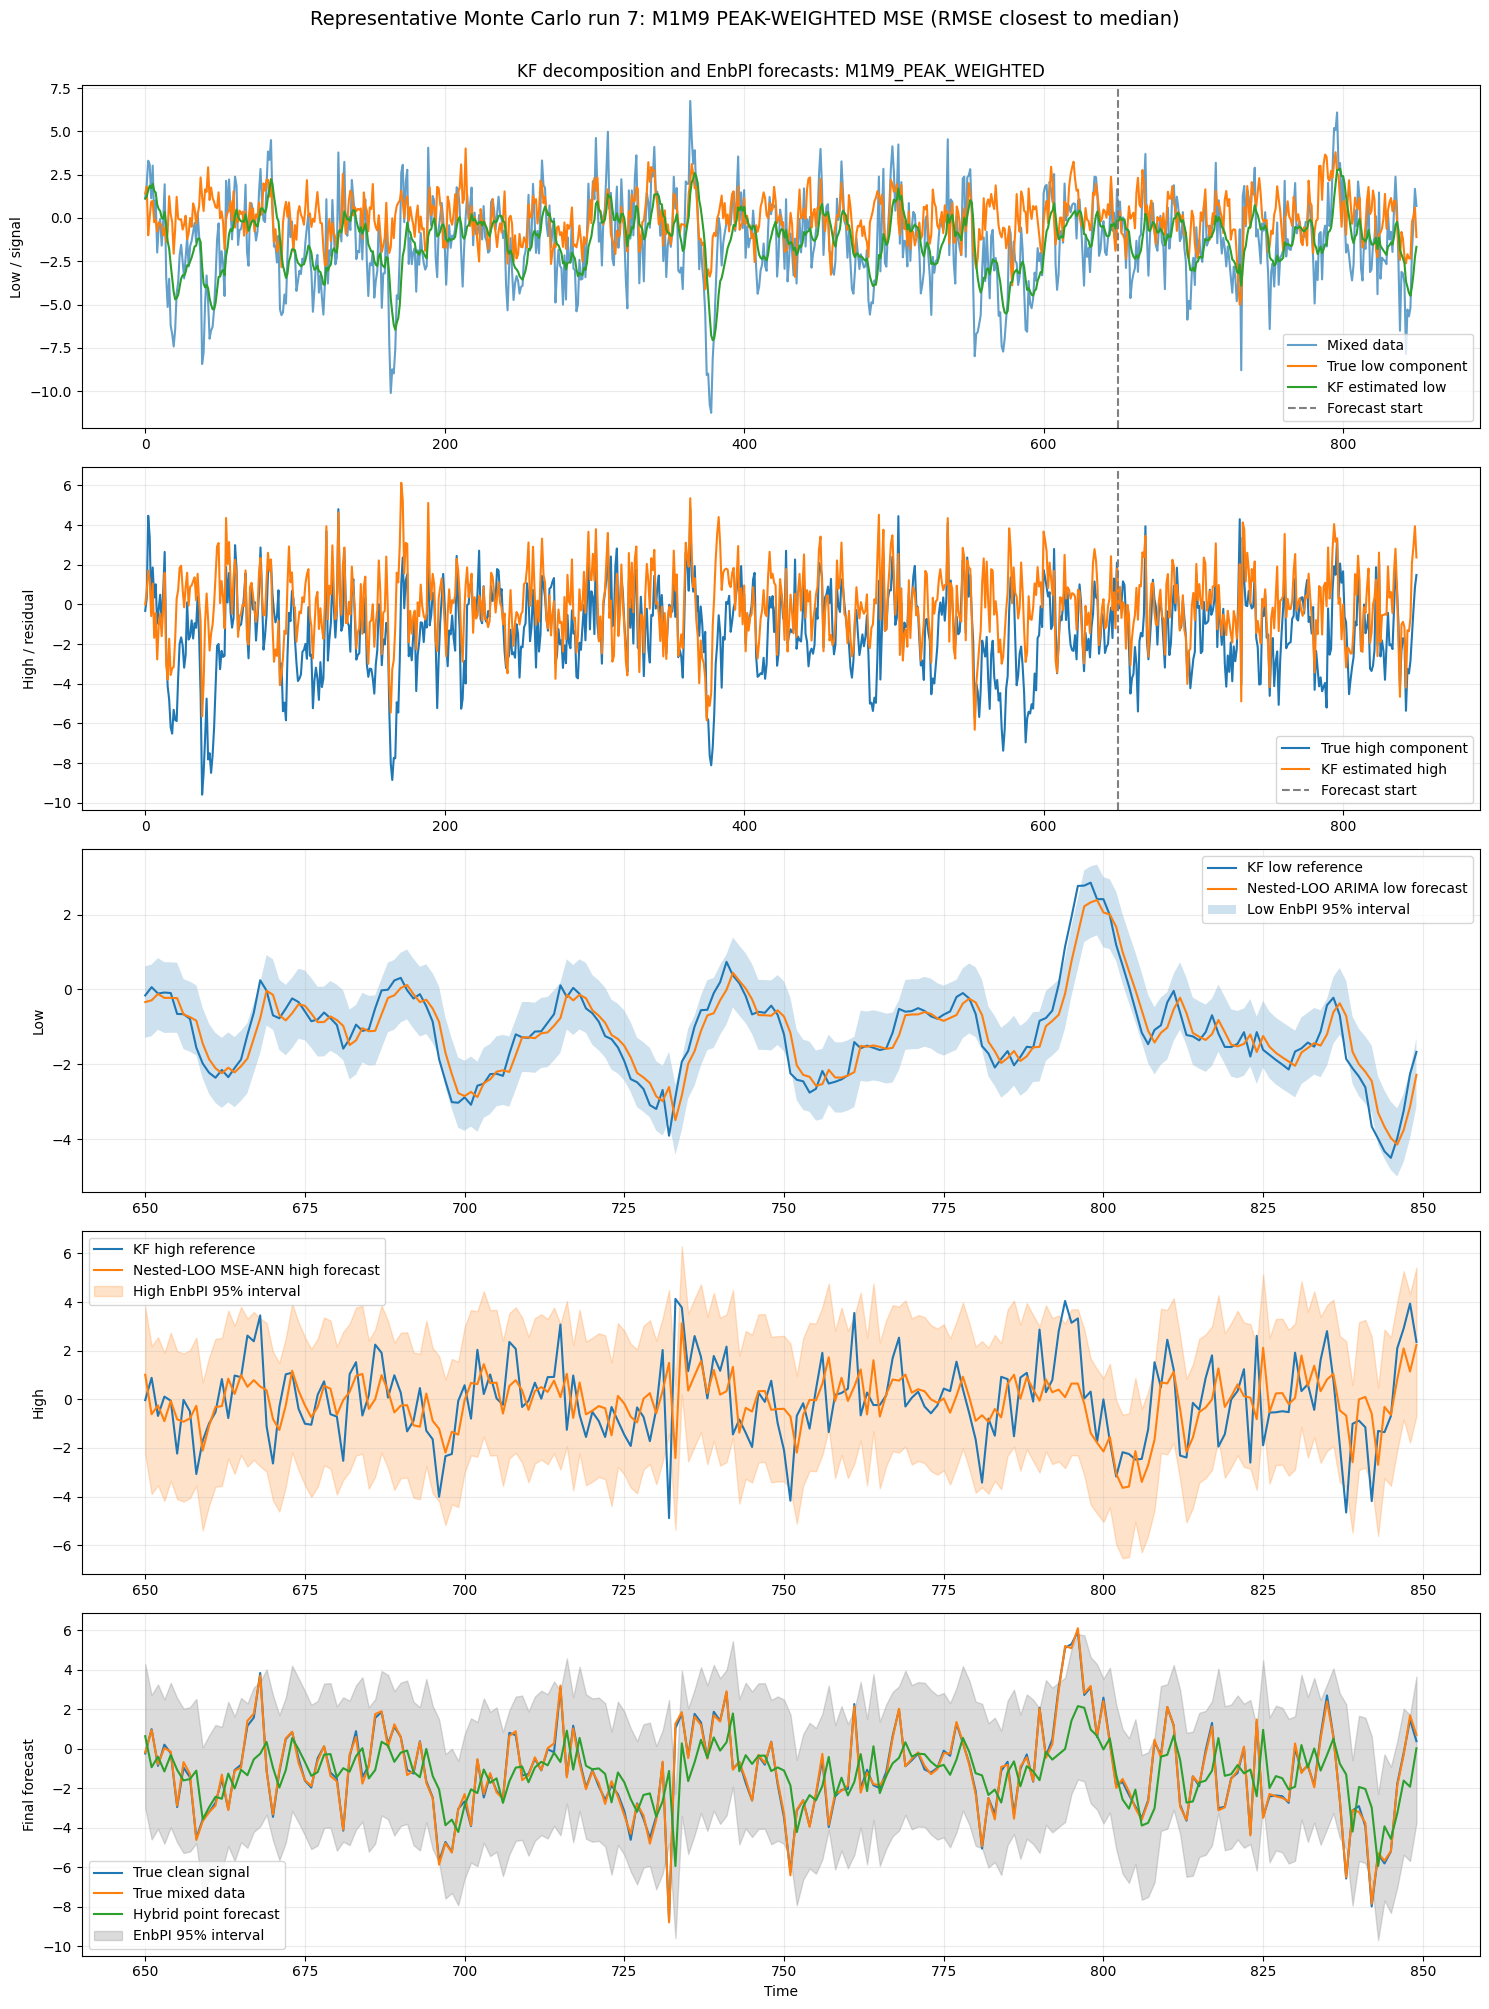

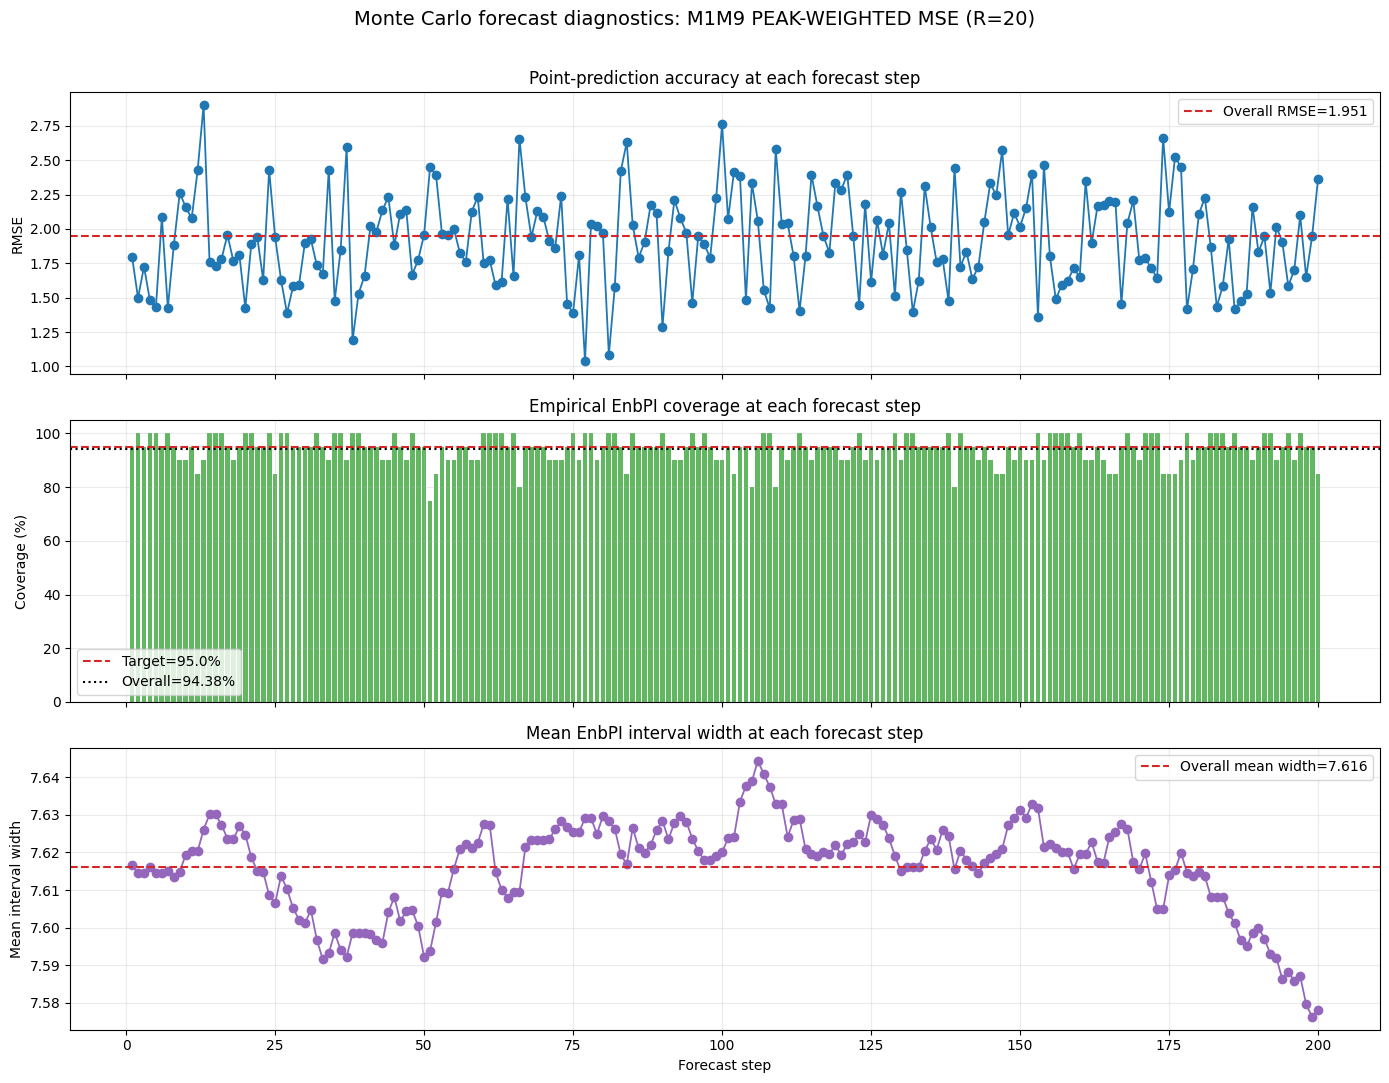

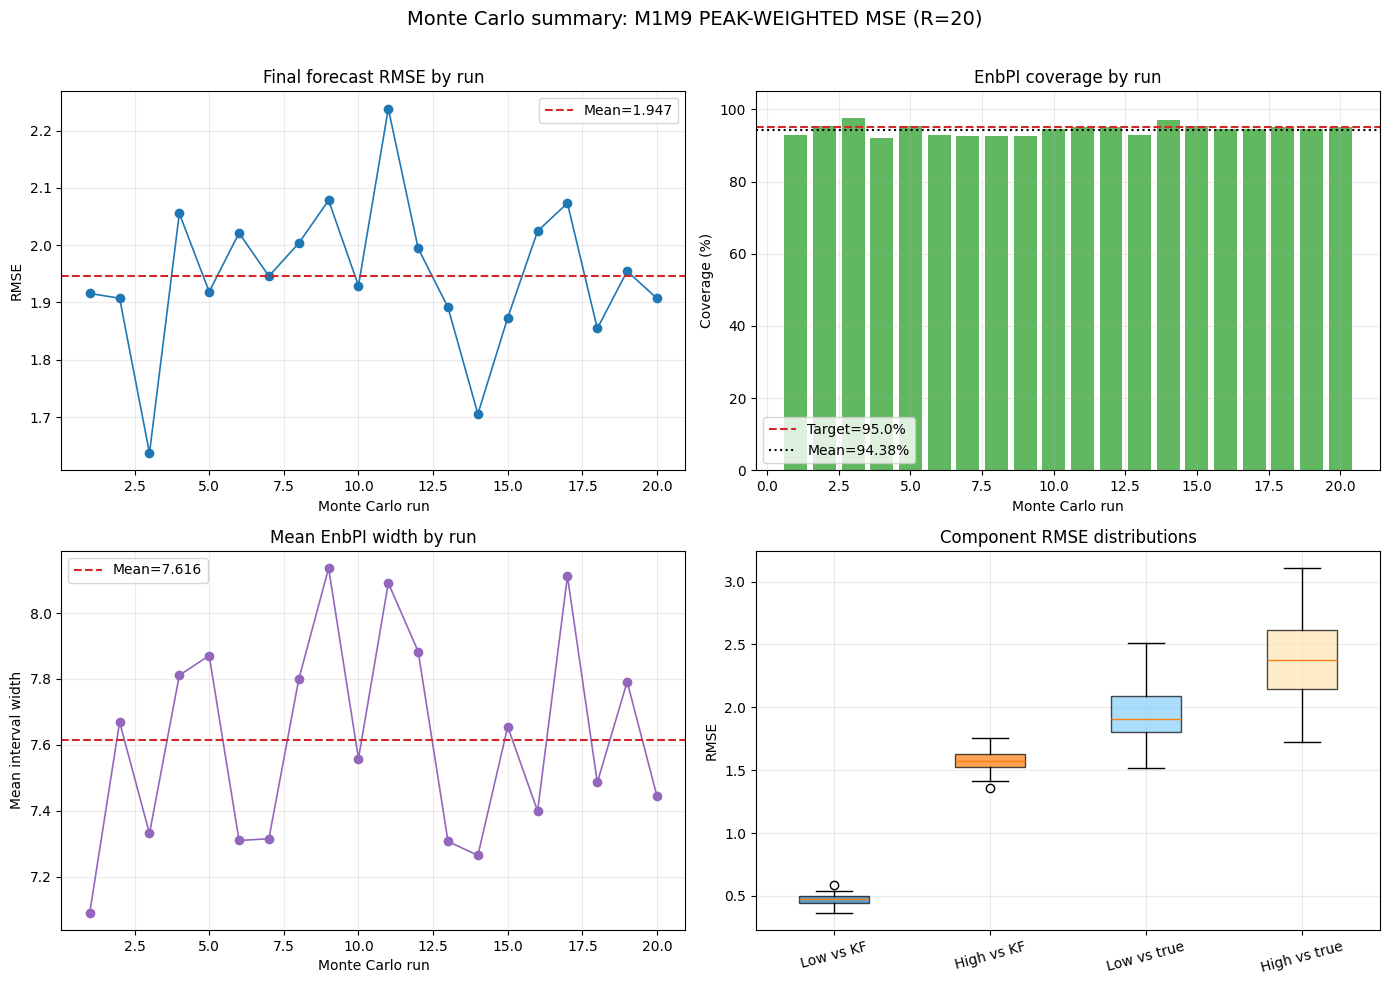

In [5]:
weighted_detail, weighted_aggregate = plot_monte_carlo_forecast_diagnostics(
    weighted_runs,
    weighted_results,
    model_name='M1M9 Peak-weighted MSE',
    alpha=weighted_config.alpha,
)
weighted_summary_fig = plot_monte_carlo_summary(
    weighted_runs,
    model_name='M1M9 Peak-weighted MSE',
    alpha=weighted_config.alpha,
)

## 判讀原則

- `tail_rmse_gain_baseline_minus_weighted > 0`：weighted ANN 對 KF 高頻尖峰比較準。
- `rmse_gain_baseline_minus_weighted > 0`：weighted ANN 連最終整體 RMSE 都改善。
- tail RMSE 改善但 final RMSE 變差：模型用一般時間點的準確度交換尖峰表現。
- amplitude ratio 上升但 tail RMSE 沒改善：模型只是放大預測，沒有真的找對尖峰。
- 所有尖峰指標都沒有改善：M1M9 的尖峰主要是不可預測 innovation，而非 ANN loss 不夠重視尖峰。